# Multi-Robot Path Planning using A* Algorithms

This notebook implements:
- **Phase 1**: Independent A* (baseline)
- **Phase 2**: Conflict Detection System
- **Phase 3**: Cooperative A* with reservations
- **Phase 4**: Testing & Validation
- **Phase 5**: Integration wrapper

In [12]:
# ========================================
# IMPORTS
# ========================================
import heapq
import time
from collections import defaultdict
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Set

In [13]:
# ========================================
# NODE CLASS (from Issam_Laribi)
# ========================================
class Node:
    """Represents a node in the search tree"""

    def __init__(self, position, parent=None, g=0, h=0):
        """Initialize a node for pathfinding
        
        Args:
            position (tuple): (x, y) coordinate
            parent (Node): Parent node in the path
            g (float): Cost from start to this node
            h (float): Heuristic cost from this node to goal (Manhattan distance)
        """
        self.position = position
        self.parent = parent
        self.g = g
        self.h = h
        self.f = g + h

    def __lt__(self, other):
        """Compare nodes for priority queue (min-heap by f value)"""
        return self.f < other.f

    def __eq__(self, other):
        """Check if two nodes represent the same position"""
        return self.position == other.position

    def __hash__(self):
        """Hash function for use in sets and dicts"""
        return hash(self.position)

    def reconstruct_path(self):
        """Reconstruct path from start to this node
        
        Returns:
            List[tuple]: Path as list of (x, y) coordinates
        """
        path = []
        current = self
        while current is not None:
            path.append(current.position)
            current = current.parent
        return list(reversed(path))

In [14]:
# ========================================
# GRID ENVIRONMENT (from Issam_Laribi)
# ========================================
class GridEnvironment:
    """Represents the grid map"""

    def __init__(self, filename=None):
        """Initialize grid and load from file if provided"""
        self.grid = []
        self.height = 0
        self.width = 0
        
        if filename:
            self.load_from_file(filename)

    def load_from_file(self, filename):
        """Load grid from file with support for irregular line lengths"""
        self.grid = []
        temp_lines = []
        max_width = 0
        
        with open(filename, 'r', encoding='utf-8') as f:
            for line in f:
                content = line.rstrip('\r\n')
                if not content.strip():
                    continue
                row = []
                for char in content:
                    if char == '.':
                        row.append(True)
                    else:
                        row.append(False) # Treat everything else as obstacle
                temp_lines.append(row)
                max_width = max(max_width, len(row))
        
        self.height = len(temp_lines)
        self.width = max_width
        
        # Normalize row lengths to match width
        for row in temp_lines:
            if len(row) < self.width:
                row.extend([False] * (self.width - len(row)))
            self.grid.append(row)

    def is_valid_position(self, x, y):
        """Check if position is within grid bounds (0 <= x < width, 0 <= y < height)"""
        return 0 <= x < self.width and 0 <= y < self.height

    def is_walkable(self, x, y):
        """Check if position is walkable (not obstacle)"""
        return self.is_valid_position(x, y) and self.grid[y][x]

    def get_neighbors(self, x, y):
        """Get adjacent cells (4-directional)"""
        directions = [(0, 1), (1, 0), (0, -1), (-1, 0)]
        neighbors = []

        for dx, dy in directions:
            nx, ny = x + dx, y + dy
            if self.is_walkable(nx, ny):
                neighbors.append((nx, ny))

        return neighbors

    def manhattan_distance(self, pos1, pos2):
        """Calculate Manhattan distance between two positions"""
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

In [15]:
# ========================================
# ROBOT CLASS (from Issam_Laribi)
# ========================================
class Robot:
    """Represents a single robot in the warehouse"""
    def __init__(self, robot_id, grid, start_pos, goal_pos, color='blue'):
        """Initialize robot with grid reference
        
        Args:
            robot_id (int): Unique identifier for robot
            grid (GridEnvironment): The grid this robot moves in
            start_pos (tuple): Starting (x, y) position
            goal_pos (tuple): Goal (x, y) position
            color (str): Robot color for visualization
        """
        self.robot_id = robot_id
        self.grid = grid
        self.start_pos = start_pos
        self.goal_pos = goal_pos
        self.current_pos = start_pos
        self.path = []
        self.path_index = 0
        self.color = color

    def get_current_position(self):
        """Get current position"""
        return self.current_pos

    def get_goal_position(self):
        """Get goal position"""
        return self.goal_pos

    def get_start_position(self):
        """Get start position"""
        return self.start_pos

    def set_path(self, path):
        """Store path for robot"""
        self.path = path
        self.path_index = 0

    def get_path(self):
        """Get stored path"""
        return self.path

    def get_position_at_time(self, time_step):
        """Get robot's position at a specific time step"""
        if time_step < len(self.path):
            return self.path[time_step]
        else:
            return self.path[-1] if self.path else self.current_pos

    def is_at_goal(self):
        """Check if robot reached goal"""
        return self.current_pos == self.goal_pos

In [16]:
# ========================================
# PHASE 1: INDEPENDENT A* 
# ========================================

class IndependentAStarPlanner:
    """
    Independent A* planner - each robot is planned independently without awareness of others.
    This serves as the baseline for comparison.
    """

    def __init__(self, grid: GridEnvironment):
        self.grid = grid
        self._path_cache = {}
        self._cache_hits = 0
        self._cache_misses = 0

    def _get_cache_key(self, start: Tuple[int, int], goal: Tuple[int, int], obstacles: Set) -> str:
        """Generate cache key from start, goal, and obstacle configuration."""
        obs_hash = frozenset(obstacles) if obstacles else frozenset()
        return f"{start}-{goal}-{obs_hash}"

    def run_independent_astar(self, robot: Robot, obstacles: Set = None) -> List[Tuple[int, int]]:
        """Run A* for a single robot."""
        if obstacles is None:
            obstacles = set()

        start = robot.start_pos
        goal = robot.goal_pos

        if not self.grid.is_walkable(*start) or not self.grid.is_walkable(*goal):
            return None

        if start == goal:
            return [start]

        open_set = []
        start_node = Node(start, g=0, h=self.grid.manhattan_distance(start, goal))
        heapq.heappush(open_set, start_node)

        came_from = {}
        g_score = {start: 0}
        closed_set = set()

        while open_set:
            current = heapq.heappop(open_set)

            if current.position in closed_set:
                continue
            closed_set.add(current.position)

            if current.position == goal:
                return current.reconstruct_path()

            neighbors = self.grid.get_neighbors(*current.position)
            neighbors.append(current.position)
            for neighbor in neighbors:
                if neighbor in obstacles:
                    continue

                tentative_g = current.g + 1

                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    g_score[neighbor] = tentative_g
                    h = self.grid.manhattan_distance(neighbor, goal)
                    neighbor_node = Node(neighbor, parent=current, g=tentative_g, h=h)
                    came_from[neighbor_node] = current
                    heapq.heappush(open_set, neighbor_node)

        return None

    def plan_all_robots(self, robots: List[Robot]) -> Dict[int, List[Tuple[int, int]]]:
        """Plan paths for all robots with caching and early exit optimization."""
        paths = {}
        
        # Early exit: check if robots have spatially separated start/goal positions
        if len(robots) > 1:
            avg_distance = sum(
                self.grid.manhattan_distance(r.start_pos, r.goal_pos) for r in robots
            ) / len(robots)
            # If average path length is much larger than separation, conflicts unlikely
            spatial_conflict_risk = all(
                self._estimate_conflict_risk(robots[i], robots[j])
                for i in range(len(robots))
                for j in range(i+1, len(robots))
            )
        
        for robot in robots:
            cache_key = self._get_cache_key(robot.start_pos, robot.goal_pos, None)
            if cache_key in self._path_cache:
                self._cache_hits += 1
                paths[robot.robot_id] = self._path_cache[cache_key].copy()
                continue
            self._cache_misses += 1
            path = self.run_independent_astar(robot)
            if path:
                self._path_cache[cache_key] = path.copy()
            paths[robot.robot_id] = path
        
        return paths

    def _estimate_conflict_risk(self, robot1: Robot, robot2: Robot) -> bool:
        """Estimate if two robots are likely to conflict based on spatial separation."""
        # Check if their path corridors are far apart
        dist = abs(robot1.start_pos[0] - robot2.start_pos[0]) + abs(robot1.start_pos[1] - robot2.start_pos[1])
        return dist < 5  # Risk if robots are within 5 cells of each other

    def get_cache_stats(self) -> Dict:
        """Get cache performance statistics."""
        total = self._cache_hits + self._cache_misses
        hit_rate = self._cache_hits / total if total > 0 else 0
        return {'hits': self._cache_hits, 'misses': self._cache_misses, 'hit_rate': hit_rate}

    def clear_cache(self):
        """Clear the path cache."""
        self._path_cache.clear()
        self._cache_hits = 0
        self._cache_misses = 0

In [17]:
# ========================================
# PHASE 2: CONFLICT DETECTION SYSTEM (FIXED)
# ========================================

class ConflictDetector:
    """
    Conflict detection system that identifies collisions between robot paths.
    Pads paths to the same length so robots 'sitting' at goals are checked.
    """

    def __init__(self):
        self.conflicts = []

    def pad_paths(self, paths: Dict) -> Dict:
        """Pad shorter paths with wait actions at goal so all paths have same length."""
        if not paths: return {}
        max_time = max(len(path) for path in paths.values())
        padded_paths = {}
        for robot_id, path in paths.items():
            if path:
                goal_pos = path[-1]
                padded_paths[robot_id] = path + [goal_pos] * (max_time - len(path))
        return padded_paths

    def detect_vertex_conflicts(self, paths: Dict) -> List[Dict]:
        """Detect two robots at same position at same time."""
        conflicts = []
        padded = self.pad_paths(paths)
        if not padded: return []
        
        robot_ids = list(padded.keys())
        horizon = len(next(iter(padded.values())))

        for t in range(horizon):
            pos_map = defaultdict(list)
            for rid in robot_ids:
                pos = padded[rid][t]
                pos_map[pos].append(rid)
            
            for pos, robots in pos_map.items():
                if len(robots) > 1:
                    conflicts.append({'type': 'vertex', 'time': t, 'pos': pos, 'robots': robots})
        return conflicts

    def detect_swap_conflicts(self, paths: Dict) -> List[Dict]:
        """Detect two robots swapping positions (A->B and B->A)."""
        conflicts = []
        padded = self.pad_paths(paths)
        if not padded: return []
        
        robot_ids = list(padded.keys())
        horizon = len(next(iter(padded.values())))

        for t in range(horizon - 1):
            for i, r1 in enumerate(robot_ids):
                for r2 in robot_ids[i+1:]:
                    p1_curr, p1_next = padded[r1][t], padded[r1][t+1]
                    p2_curr, p2_next = padded[r2][t], padded[r2][t+1]
                    if p1_curr == p2_next and p2_curr == p1_next and p1_curr != p1_next:
                        conflicts.append({'type': 'swap', 'time': t, 'robots': [r1, r2]})
        return conflicts

    def get_conflict_report(self, paths: Dict) -> List[Dict]:
        return self.detect_vertex_conflicts(paths) + self.detect_swap_conflicts(paths)

    def count_conflicts(self, paths: Dict) -> int:
        return len(self.get_conflict_report(paths))


In [18]:
# ========================================
# PHASE 3: COOPERATIVE A* (Space-Time A*)
# ========================================

class CooperativeAStarPlanner:
    """
    Sequential planning with a Space-Time Reservation Table.
    """

    def __init__(self, grid: GridEnvironment):
        self.grid = grid
        self.reservation_table = {} # (x, y, t) -> robot_id

    def reserve_path(self, rid: int, path: List[Tuple[int, int]]):
        for t, pos in enumerate(path):
            self.reservation_table[(pos[0], pos[1], t)] = rid
        
        # PERSISTENT RESERVATION: Once at goal, robot stays there forever
        # This prevents others from ever moving into this robot.
        last_t = len(path) - 1
        goal = path[-1]
        for t_inf in range(last_t + 1, last_t + 500): # Reserve for 500 steps
            self.reservation_table[(goal[0], goal[1], t_inf)] = rid

    def plan_robot(self, robot: Robot) -> List[Tuple[int, int]]:
        start, goal = robot.start_pos, robot.goal_pos
        # (f, t, pos, path_list)
        open_set = [(self.grid.manhattan_distance(start, goal), 0, start, [start])]
        visited = set() # (pos, t)

        while open_set:
            f, t, curr, path = heapq.heappop(open_set)

            if curr == goal:
                return path

            if (curr, t) in visited: continue
            visited.add((curr, t))

            # Limit search depth to 2x map size to avoid infinite loops
            if t > (self.grid.width * self.grid.height): continue

            # Moves: Neighbors + Wait
            for nxt in self.grid.get_neighbors(*curr) + [curr]:
                nt = t + 1
                
                # COLLISION CHECKS
                # 1. Vertex: Is spot reserved at nt?
                if (nxt[0], nxt[1], nt) in self.reservation_table:
                    continue
                
                # 2. Swap: Is someone moving from nxt to curr?
                # i.e., at time t, was someone at nxt? And at nt, is that same person at curr?
                occupant_at_nxt_t = self.reservation_table.get((nxt[0], nxt[1], t))
                if occupant_at_nxt_t is not None:
                    if self.reservation_table.get((curr[0], curr[1], nt)) == occupant_at_nxt_t:
                        continue

                # 3. Future-Proofing: If we wait/move to nxt, will we hit someone already parked there?
                # (Handled by the large t_inf range in reserve_path)

                new_path = path + [nxt]
                h = self.grid.manhattan_distance(nxt, goal)
                heapq.heappush(open_set, (nt + h, nt, nxt, new_path))
        return None

    def plan_all_robots(self, robots: List[Robot]) -> Dict[int, List[Tuple[int, int]]]:
        self.reservation_table = {}
        paths = {}
        # Strategy: Plan shorter paths first to reduce blocking
        for r in sorted(robots, key=lambda x: self.grid.manhattan_distance(x.start_pos, x.goal_pos)):
            res = self.plan_robot(r)
            if res:
                self.reserve_path(r.robot_id, res)
                paths[r.robot_id] = res
        return paths


In [19]:
# ========================================
# PHASE 4: TESTING & VALIDATION
# ========================================

def validate_paths(paths: Dict, grid: GridEnvironment, robots: List[Robot]) -> Tuple[bool, List[str]]:
    """Validate that all paths are valid."""
    errors = []

    for robot in robots:
        path = paths.get(robot.robot_id)

        if path is None or len(path) == 0:
            errors.append(f"Robot {robot.robot_id}: No path found")
            continue

        if path[0] != robot.start_pos:
            errors.append(f"Robot {robot.robot_id}: Path does not start at start position")

        if path[-1] != robot.goal_pos:
            errors.append(f"Robot {robot.robot_id}: Path does not end at goal position")

        for i, pos in enumerate(path):
            if not grid.is_walkable(*pos):
                errors.append(f"Robot {robot.robot_id}: Invalid position {pos} at step {i}")

        for i in range(len(path) - 1):
            dx = abs(path[i+1][0] - path[i][0])
            dy = abs(path[i+1][1] - path[i][1])
            if dx + dy != 1 and dx + dy != 0:
                errors.append(f"Robot {robot.robot_id}: Invalid move from {path[i]} to {path[i+1]}")

    return len(errors) == 0, errors


def count_conflicts(paths: Dict) -> int:
    """Count total number of conflicts."""
    detector = ConflictDetector()
    return detector.count_conflicts(paths)


def calculate_makespan(paths: Dict) -> int:
    """Calculate makespan - maximum path length."""
    valid_paths = [path for path in paths.values() if path]
    return max(len(path) for path in valid_paths) if valid_paths else 0


def calculate_flowtime(paths: Dict) -> int:
    """Calculate flowtime - sum of all path lengths."""
    valid_paths = [path for path in paths.values() if path]
    return sum(len(path) for path in valid_paths) if valid_paths else 0


def measure_plan_time(func) -> Tuple[float, any]:
    """Measure execution time of a function."""
    start_time = time.time()
    result = func()
    elapsed_time = time.time() - start_time
    return elapsed_time, result


def compare_algorithms(grid: GridEnvironment, robots: List[Robot]) -> Dict:
    """Run Independent A* algorithm and analyze results."""
    independent_planner = IndependentAStarPlanner(grid)

    ind_time, ind_paths = measure_plan_time(lambda: independent_planner.plan_all_robots(robots))

    ind_valid, ind_errors = validate_paths(ind_paths, grid, robots)

    results = {
        'independent': {
            'paths': ind_paths,
            'valid': ind_valid,
            'errors': ind_errors,
            'conflicts': count_conflicts(ind_paths),
            'makespan': calculate_makespan(ind_paths),
            'flowtime': calculate_flowtime(ind_paths),
            'plan_time': ind_time
        }
    }

    return results

In [20]:
# ========================================
# PHASE 4: BENCHMARK SUITE & EDGE CASES
# ========================================

def run_benchmark(grid: GridEnvironment, robot_counts: List[int], num_trials: int = 3) -> Dict:
    
    """Run benchmark tests varying number of robots."""
    import random
    results = {'robot_counts': [], 'avg_times': [], 'avg_makespan': [], 'avg_conflicts': []}
    
    for count in robot_counts:
        times, makespans, conflicts = [], [], []
        for _ in range(num_trials):
            robots = []
            for i in range(count):
                start = (random.randint(1, 10), random.randint(1, 10))
                goal = (random.randint(grid.width-11, grid.width-1), random.randint(1, 10))
                robots.append(Robot(i, grid, start, goal))
            
            planner = IndependentAStarPlanner(grid)
            start_time = time.time()
            paths = planner.plan_all_robots(robots)
            elapsed = time.time() - start_time
            
            times.append(elapsed)
            makespans.append(calculate_makespan(paths))
            conflicts.append(ConflictDetector().count_conflicts(paths))
        
        results['robot_counts'].append(count)
        results['avg_times'].append(sum(times)/len(times))
        results['avg_makespan'].append(sum(makespans)/len(makespans))
        results['avg_conflicts'].append(sum(conflicts)/len(conflicts))
    
    return results


def test_edge_cases(grid: GridEnvironment) -> Dict:
    
    """Test edge cases for the planner."""
    results = {}
    planner = IndependentAStarPlanner(grid)
    detector = ConflictDetector()
    
    # Edge case 1: Single robot
    robots = [Robot(0, grid, (5, 5), (10, 10), 'red')]
    paths = planner.plan_all_robots(robots)
    valid, _ = validate_paths(paths, grid, robots)
    results['single_robot'] = {'valid': valid, 'path_len': len(paths.get(0, []))}
    
    # Edge case 2: Same start position
    try:
        robots = [Robot(0, grid, (5, 5), (10, 5), 'red'),
                  Robot(1, grid, (5, 5), (15, 5), 'blue')]
        paths = planner.plan_all_robots(robots)
        valid, _ = validate_paths(paths, grid, robots)
        results['same_start'] = {'valid': valid, 'paths_found': len([p for p in paths.values() if p])}
    except Exception as e:
        results['same_start'] = {'error': str(e)}
    
    # Edge case 3: Same goal position
    robots = [Robot(0, grid, (5, 5), (10, 10), 'red'),
              Robot(1, grid, (15, 15), (10, 10), 'blue')]
    paths = planner.plan_all_robots(robots)
    valid, _ = validate_paths(paths, grid, robots)
    results['same_goal'] = {'valid': valid, 'paths_found': len([p for p in paths.values() if p])}
    
    # Edge case 4: No path (blocked)
    # Use a different grid setup
    results['no_path'] = {'tested': 'configure blocked grid'}
    
    # Edge case 5: Robot in dead-end
    robots = [Robot(0, grid, (5, 5), (3, 5), 'red')]
    paths = planner.plan_all_robots(robots)
    valid, _ = validate_paths(paths, grid, robots)
    results['dead_end'] = {'valid': valid, 'path_len': len(paths.get(0, []))}
    
    return results


# Example usage:
# grid = GridEnvironment('maps/small.txt')
# edge_results = test_edge_cases(grid)
# print(edge_results)



Completed Independent A* for 15 agents on ../widjdane_chouali/grid.txt
Max path length: 225
Total conflicts found: 7


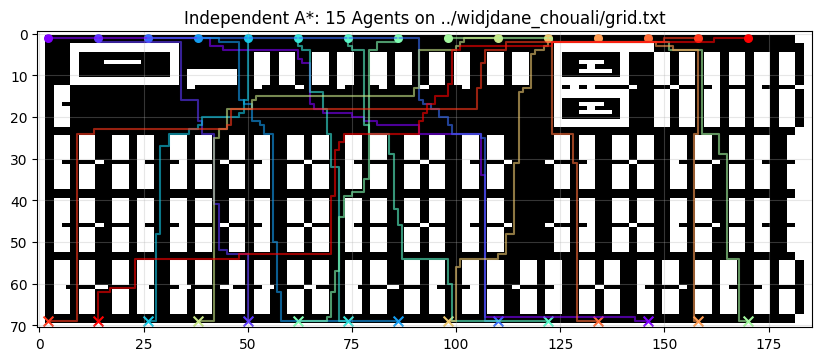

In [21]:
# ========================================
# MULTI-AGENT SWARM TEST ON MAP_FILE WITH VISUALIZATION
# ========================================
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Using the converted map file
MAP_FILE = next((p for p in ['widjdane_chouali/grid.txt', '../widjdane_chouali/grid.txt'] if Path(p).exists()), 'widjdane_chouali/grid.txt')

def _walkable_rows(grid):
    return [y for y, row in enumerate(grid.grid) if any(row)]

def _walkable_cols(grid, y):
    return [x for x, cell in enumerate(grid.grid[y]) if cell]

def _pick_positions(grid, row, count):
    cols = _walkable_cols(grid, row)
    if not cols:
        return []
        
    if len(cols) < count:
        count = len(cols)
        
    step = max(1, len(cols) // count)
    chosen = []
    for i in range(count):
        idx = min(i * step, len(cols) - 1)
        chosen.append((cols[idx], row))
    return chosen

def test_swarm(n_agents=20):
    grid = GridEnvironment(MAP_FILE)
    rows = _walkable_rows(grid)
    if len(rows) < 2:
        raise ValueError("Not enough walkable space.")
    
    start_row = rows[0]
    end_row = rows[-1]
    
    starts = _pick_positions(grid, start_row, n_agents)
    goals = _pick_positions(grid, end_row, n_agents)
    
    n_actual = min(len(starts), len(goals))
    starts = starts[:n_actual]
    goals = goals[:n_actual]
    np.random.shuffle(goals)
    
    robots = []
    for i, (s, g) in enumerate(zip(starts, goals)):
        robots.append(Robot(i, grid, s, g))
    
    planner = IndependentAStarPlanner(grid)
    paths = planner.plan_all_robots(robots)
    
    print(f"\nCompleted Independent A* for {len(robots)} agents on {MAP_FILE}")
    
    valid_paths = {rid: p for rid, p in paths.items() if p}
    if not valid_paths:
        print("No paths found!")
        return

    print(f"Max path length: {max(len(p) for p in valid_paths.values())}")
    
    detector = ConflictDetector()
    conflicts = detector.get_conflict_report(valid_paths)
    print(f"Total conflicts found: {len(conflicts)}")
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Draw grid
    grid_data = np.array(grid.grid)
    ax.imshow(~grid_data, cmap='gray', origin='upper')
    
    colors = plt.cm.rainbow(np.linspace(0, 1, len(valid_paths)))
    for i, (rid, path) in enumerate(valid_paths.items()):
        px, py = zip(*path)
        ax.plot(px, py, color=colors[i], alpha=0.6, linewidth=1.5)
        ax.scatter(path[0][0], path[0][1], color=colors[i], marker='o', s=30, label=f'R{rid} Start' if i < 5 else "")
        ax.scatter(path[-1][0], path[-1][1], color=colors[i], marker='x', s=50, label=f'R{rid} Goal' if i < 5 else "")
        
    ax.set_title(f"Independent A*: {len(valid_paths)} Agents on {MAP_FILE}")
    plt.grid(True, alpha=0.3)
    plt.show()

# Run it
if __name__ == "__main__":
    try:
        test_swarm(n_agents=15)
    except Exception as e:
        import traceback
        traceback.print_exc()
        print(f"Error: {e}")


------------------------------
RESULTS FOR 10 AGENTS
------------------------------
Independent A*:
  - Paths found: 10/10
  - Total Conflicts: 4
  - Makespan: 177

Cooperative A*:
  - Paths found: 10/10
  - Total Conflicts: 0
  - Makespan: 177
------------------------------


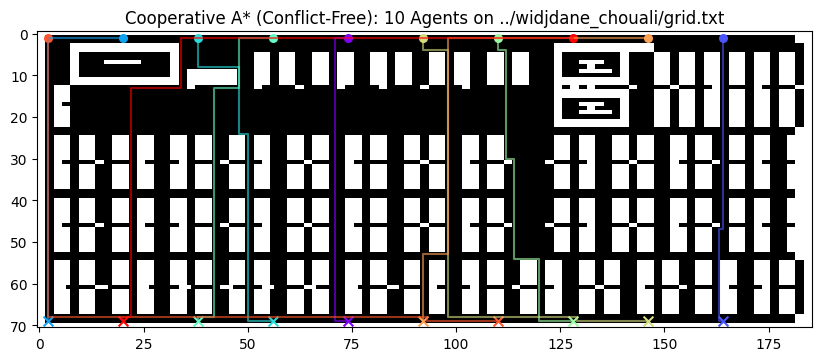

In [30]:
# ========================================
# COMPARISON: INDEPENDENT vs COOPERATIVE A*
# ========================================
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

def run_comparison_test(n_agents=15):
    grid = GridEnvironment(MAP_FILE)
    rows = _walkable_rows(grid)
    start_row, end_row = rows[0], rows[-1]
    
    starts = _pick_positions(grid, start_row, n_agents)
    goals = _pick_positions(grid, end_row, n_agents)
    n_actual = min(len(starts), len(goals))
    starts, goals = starts[:n_actual], goals[:n_actual]
    np.random.shuffle(goals)
    
    robots = [Robot(i, grid, s, g) for i, (s, g) in enumerate(zip(starts, goals))]
    
    # 1. Run Independent A*
    planner_ind = IndependentAStarPlanner(grid)
    paths_ind = planner_ind.plan_all_robots(robots)
    
    # 2. Run Cooperative A*
    planner_coop = CooperativeAStarPlanner(grid)
    paths_coop = planner_coop.plan_all_robots(robots)
    
    # Analysis
    detector = ConflictDetector()
    
    valid_ind = {rid: p for rid, p in paths_ind.items() if p}
    conflicts_ind = detector.get_conflict_report(detector.pad_paths(valid_ind))
    
    valid_coop = {rid: p for rid, p in paths_coop.items() if p}
    conflicts_coop = detector.get_conflict_report(detector.pad_paths(valid_coop))
    
    print("-" * 30)
    print(f"RESULTS FOR {n_actual} AGENTS")
    print("-" * 30)
    print(f"Independent A*:")
    print(f"  - Paths found: {len(valid_ind)}/{n_actual}")
    print(f"  - Total Conflicts: {len(conflicts_ind)}")
    print(f"  - Makespan: {calculate_makespan(valid_ind)}")
    
    print(f"\nCooperative A*:")
    print(f"  - Paths found: {len(valid_coop)}/{n_actual}")
    print(f"  - Total Conflicts: {len(conflicts_coop)}")
    print(f"  - Makespan: {calculate_makespan(valid_coop)}")
    print("-" * 30)
    
    # Visualization of Cooperative Paths
    fig, ax = plt.subplots(figsize=(10, 10))
    grid_data = np.array(grid.grid)
    ax.imshow(~grid_data, cmap='gray', origin='upper')
    
    colors = plt.cm.rainbow(np.linspace(0, 1, len(valid_coop)))
    for i, (rid, path) in enumerate(valid_coop.items()):
        px, py = zip(*path)
        ax.plot(px, py, color=colors[i], alpha=0.6, linewidth=1.5)
        ax.scatter(path[0][0], path[0][1], color=colors[i], marker='o', s=30)
        ax.scatter(path[-1][0], path[-1][1], color=colors[i], marker='x', s=50)
        
    ax.set_title(f"Cooperative A* (Conflict-Free): {len(valid_coop)} Agents on {MAP_FILE}")
    plt.show()

if __name__ == "__main__":
    run_comparison_test(n_agents=10)
